### Implementation of Sparse Identification of Nonlinear Dynamics (SINDy)

Author: Phoebe Kuang

Date: May 7, 2026

_Note: Please run the following commands in your terminal to set up the environment and install the required packages for this notebook._

`conda create --name sindy_env python=3.11 scipy matplotlib notebook -y`

`conda activate sindy_env`

`pip install pysindy`

_Please make sure to select the `sindy_env` kernel in your Jupyter Notebook to run the code successfully._


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pysindy as ps
import derivative
print("PySINDy Version:", ps.__version__)

PySINDy Version: 2.1.0


In this project, we will first generate data from two classical dynamical systems. Then we will implement SINDy algorithm (using `PySINDy` package) and test it on the two systems, namely Lorenz system and Brusselator Oscillator to see whether it is able to recover the sparse model as expected. Furthermore, we will explore how the method fails due to: (1) missing terms from the true model in the library (Brusselator), and (2) low sampling rate of the data (Lorenz).

---

#### Part 1: Dynamical Systems
- The Lorenz Attractor (3D Chaotic ODE)
- The Brusselator (2D Mass-Action Chemical Oscillator)

Lorenz Data:
Time shape: (25000,)
State matrix (X) shape: (25000, 3)



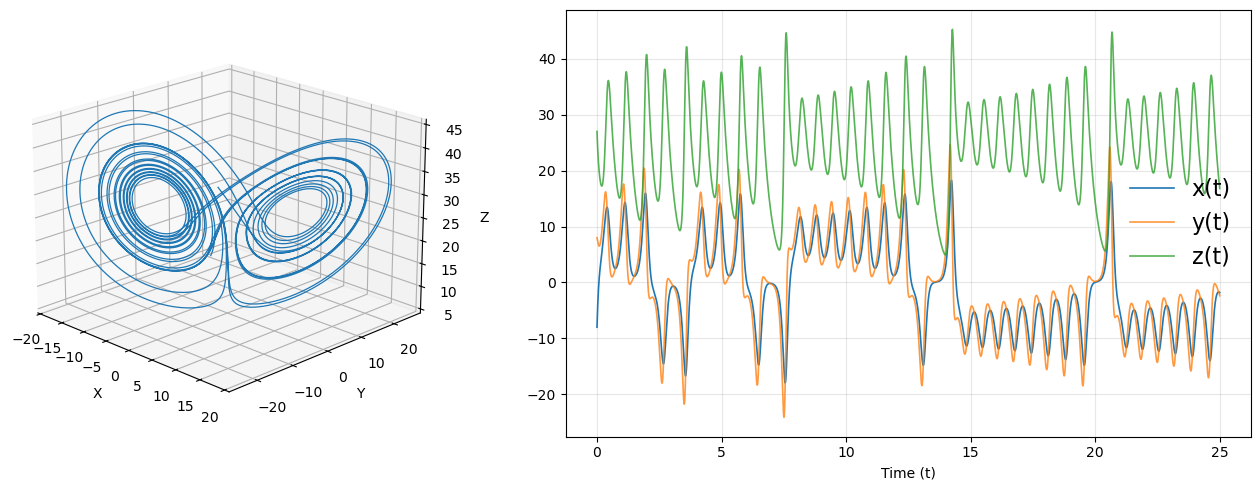

In [2]:
# SYSTEM 1: LORENZ ATTRACTOR

# Equations
def lorenz_deriv(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    return [
        sigma * (y - x), 
        x * (rho - z) - y, 
        x * y - beta * z
    ]

# Generate Training Data using LSODA (As suggested in the PySINDY User Guide)
dt_lor = 0.001
t_max_lor = 25.0
t_lor = np.arange(0, t_max_lor, dt_lor)
initial_state_lor = [-8.0, 8.0, 27.0]

sol_lor = solve_ivp(
    lorenz_deriv, 
    t_span=(0, t_max_lor), 
    y0=initial_state_lor, 
    t_eval=t_lor, 
    method='LSODA',
    rtol=1e-12, atol=1e-12
)

# State matrix X (Rows = time steps, Columns = variables x, y, z)
X_lor = sol_lor.y.T 

print("Lorenz Data:")
print(f"Time shape: {t_lor.shape}")
print(f"State matrix (X) shape: {X_lor.shape}\n")

# Visualization
fig = plt.figure(figsize=(14, 5))

# Left: Phase Portrait
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_lor[:, 0], X_lor[:, 1], X_lor[:, 2], lw=0.9, color='#1f77b4')
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.view_init(elev=20, azim=-45)

# Right: Time-Series Data (25 seconds)
ax2 = fig.add_subplot(122)
ax2.plot(t_lor, X_lor[:, 0], label='x(t)', lw=1.2)
ax2.plot(t_lor, X_lor[:, 1], label='y(t)', lw=1.2, alpha=0.8)
ax2.plot(t_lor, X_lor[:, 2], label='z(t)', lw=1.2, alpha=0.8)
ax2.set_xlabel("Time (t)")
ax2.legend(frameon=False, fontsize=16)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

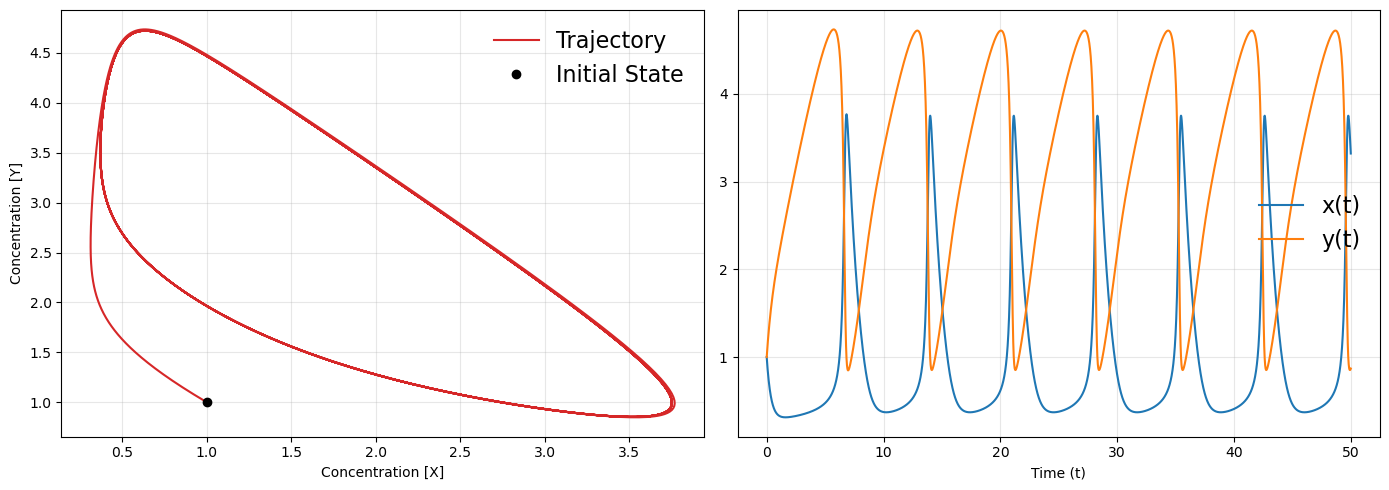

In [3]:
# SYSTEM 2: THE BRUSSELATOR

# Equations
def brusselator_deriv(t, state, A=1.0, B=3.0):
    x, y = state
    return [
        A - (B + 1) * x + (x**2) * y, 
        B * x - (x**2) * y
    ]

# Generate Training Data using LSODA
dt_brus = 0.01
t_max_brus = 50.0
t_brus = np.arange(0, t_max_brus, dt_brus)
initial_state_brus = [1.0, 1.0]

sol_brus = solve_ivp(
    brusselator_deriv, 
    t_span=(0, t_max_brus), 
    y0=initial_state_brus, 
    t_eval=t_brus, 
    method='LSODA',
    rtol=1e-12, atol=1e-12
)

X_brus = sol_brus.y.T

# Visualization
fig = plt.figure(figsize=(14, 5))

# Left: Phase Plot
ax1 = fig.add_subplot(121)
ax1.plot(X_brus[:, 0], X_brus[:, 1], lw=1.5, color='#d62728', label='Trajectory')
ax1.plot(X_brus[0, 0], X_brus[0, 1], 'ko', label='Initial State')
ax1.set_xlabel("Concentration [X]")
ax1.set_ylabel("Concentration [Y]")
ax1.legend(frameon=False, fontsize=16)
ax1.grid(True, alpha=0.3)

# Right: Time-Series Data
ax2 = fig.add_subplot(122)
ax2.plot(t_brus, X_brus[:, 0], label='x(t)', lw=1.5, color='#1f77b4')
ax2.plot(t_brus, X_brus[:, 1], label='y(t)', lw=1.5, color='#ff7f0e')
ax2.set_xlabel("Time (t)")
ax2.legend(frameon=False, fontsize=16)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
#### Part 2: SINDy Implementation (Success Cases)

##### Success Case 1: Lorenz System

In [4]:
# Implementing SINDy on the Lorenz Data

# SINDy Configuration
# We use a 5th-degree polynomial library, 4th-order finite difference for derivatives, and STLSQ with a threshold of 0.025 for sparsity.
poly_library = ps.PolynomialLibrary(degree=5)
differentiation_method = ps.FiniteDifference(order=4)
optimizer = ps.STLSQ(threshold=0.025)

model_lor = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=poly_library,
    optimizer=optimizer
)

# Fit the model
model_lor.fit(X_lor, t=dt_lor, feature_names=["x", "y", "z"])

,optimizer,STLSQ(threshold=0.025)
,feature_library,PolynomialLibrary(degree=5)
,differentiation_method,FiniteDifference(order=4)
,degree,5
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.025
,alpha,0.05
,max_iter,20


In [5]:
# Structural Accuracy
print("\nIdentified Equations:")
model_lor.print()


Identified Equations:
(x)' = -10.000 x +  10.000 y
(y)' =  28.000 x + -1.000 y + -1.000 x z
(z)' = -2.667 z +  1.000 x y


In [6]:
# Parameter Estimation
sindy_coef_lor = model_lor.coefficients()
sindy_coef_lor

array([[ 0.        , -9.99999999,  9.99999999,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.        , 27.99999979, -0.99999995,  0.        ,  0.        ,
         0.        , -0.99999999,  0.        ,  0.        ,  0.        ,
         0.        ,  0.     

In [7]:
# Comparing Identified Coefficients to Ground Truth

# Build the true coefficient matrix
features = model_lor.get_feature_names()
true_coef_lor = np.zeros((3, len(features)))

for i, f in enumerate(features):
    # dx/dt = 10y - 10x
    if f == 'x': true_coef_lor[0, i] = -10.0
    if f == 'y': true_coef_lor[0, i] = 10.0
    # dy/dt = 28x - y - xz
    if f == 'x': true_coef_lor[1, i] = 28.0
    if f == 'y': true_coef_lor[1, i] = -1.0
    if f == 'x z': true_coef_lor[1, i] = -1.0
    # dz/dt = xy - 8/3z
    if f == 'z': true_coef_lor[2, i] = -8.0/3.0
    if f == 'x y': true_coef_lor[2, i] = 1.0

# Calculate the Mean Absolute Error between the true and identified coefficients
mae_lor = mean_absolute_error(true_coef_lor, sindy_coef_lor)
print(f"Mean Absolute Error (MAE) of coefficients: {mae_lor:.14f}")

Mean Absolute Error (MAE) of coefficients: 0.00000000178914


In [8]:
# Prediction Accuracy

model_lor.score(X_lor, t=dt_lor)

1.0

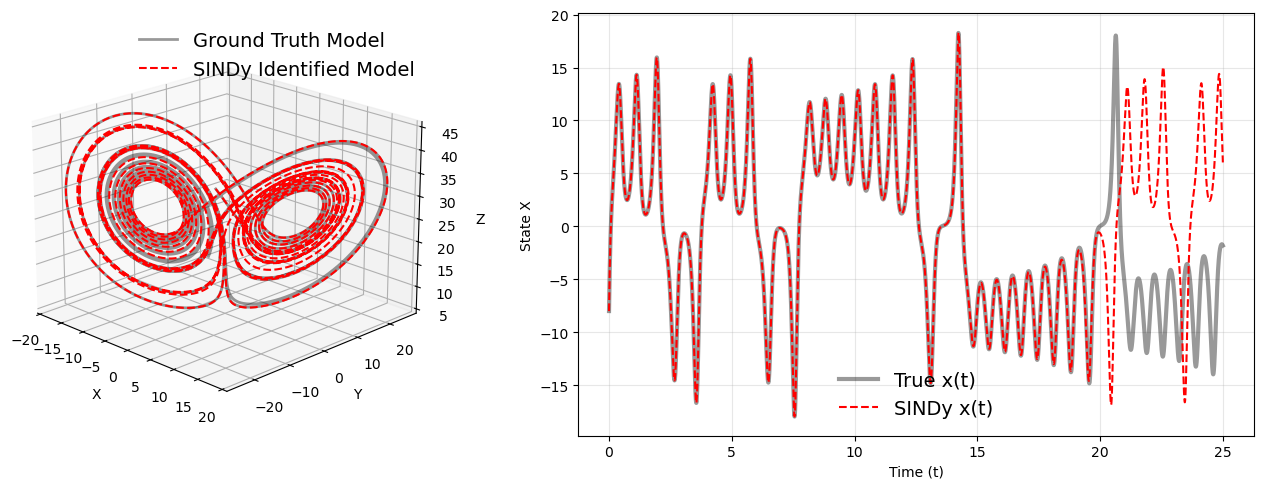

In [9]:
# Simulation Accuracy

# We simulate using the SINDy identified model. 
# Note: Because Lorenz is chaotic, tiny parametric errors can cause divergence
# We simultate for 25 seconds (Focus on short-term accuracy but divergence is expected at the end)
t_lor = np.arange(0, 25, dt_lor)
X_lor_sim = model_lor.simulate(initial_state_lor, t_lor)

fig = plt.figure(figsize=(14, 5))

# Plot 1: 3D Phase Protrait
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_lor[:, 0], X_lor[:, 1], X_lor[:, 2], 'k', lw=2, label="Ground Truth Model", alpha=0.4)
ax1.plot(X_lor_sim[:, 0], X_lor_sim[:, 1], X_lor_sim[:, 2], 'r--', lw=1.5, label="SINDy Identified Model")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.legend(frameon=False, fontsize=14)
ax1.view_init(elev=20, azim=-45)

# Plot 2: Time Series
ax2 = fig.add_subplot(122)
ax2.plot(t_lor, X_lor[:, 0], 'k', lw=3, label="True x(t)", alpha=0.4)
ax2.plot(t_lor, X_lor_sim[:, 0], 'r--', lw=1.5, label="SINDy x(t)")
ax2.set_xlabel("Time (t)")
ax2.set_ylabel("State X")
ax2.legend(frameon=False, fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Success Case 2: Brusselator System

In [10]:
# Implementing SINDy on the Brusselator Data

# SINDy Configuration
# We again use a 5th-degree polynomial library, 4th-order finite difference for derivatives
# We change STLSQ threshold to slightly higher
poly_library = ps.PolynomialLibrary(degree=3, include_bias=True)
differentiation_method = ps.FiniteDifference(order=4)
optimizer = ps.STLSQ(threshold=0.1)

model_brus = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=poly_library,
    optimizer=optimizer
)

# Fit the model
model_brus.fit(X_brus, t=dt_brus, feature_names=["x", "y"])

,optimizer,STLSQ()
,feature_library,PolynomialLibrary(degree=3)
,differentiation_method,FiniteDifference(order=4)
,degree,3
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.1
,alpha,0.05
,max_iter,20


In [11]:
# Structural Accuracy
print("\nIdentified Equations:")
model_brus.print()


Identified Equations:
(x)' =  1.000 1 + -4.000 x +  1.000 x^2 y
(y)' =  3.000 x + -1.000 x^2 y


_Note_: After playing around with different configurations of SINDy model (namely, different orders of `PolynomialLibrary`) on the Brusseletor system data, we noticed that a good choice of library order is pivotal in the success of SINDy.

Log of Trials (Different PolynomialLibrary Orders with all other settings equal):
- Success orders: 3, 4, 7, 8, 10, 11
- Failure orders: 
    - 5 (wrong dx, correct dy)
    - 6 (correct dx, wrong dy)
    - 9 (wrong dx, correct dy)

(Success := Exactly same model; Failure := Different model structure)


In [12]:
# Parameter Estimation
sindy_coef_brus = model_brus.coefficients()
sindy_coef_brus

array([[ 0.99999875, -3.99999502,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.99999878,  0.        ,  0.        ],
       [ 0.        ,  2.9999963 ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , -0.99999894,  0.        ,  0.        ]])

In [13]:
# Comparing Identified Coefficients to Ground Truth

# Build the true coefficient matrix

# Standard parameters were A=1, B=3
# dx/dt = 1 - 4x + x^2 y
# dy/dt = 3x - x^2 y
features_b = model_brus.get_feature_names()
true_coef_brus = np.zeros((2, len(features_b)))

for i, f in enumerate(features_b):
    # dx/dt
    if f == '1': true_coef_brus[0, i] = 1.0
    if f == 'x': true_coef_brus[0, i] = -4.0
    if f == 'x^2 y': true_coef_brus[0, i] = 1.0
    # dy/dt
    if f == 'x': true_coef_brus[1, i] = 3.0
    if f == 'x^2 y': true_coef_brus[1, i] = -1.0

mae_brus = mean_absolute_error(true_coef_brus, sindy_coef_brus)
print(f"Mean Absolute Error (MAE) of coefficients: {mae_brus:.14f}")


Mean Absolute Error (MAE) of coefficients: 0.00000061072748


In [14]:
# Prediction Accuracy

model_brus.score(X_brus, t=dt_brus)

0.9999999999566285

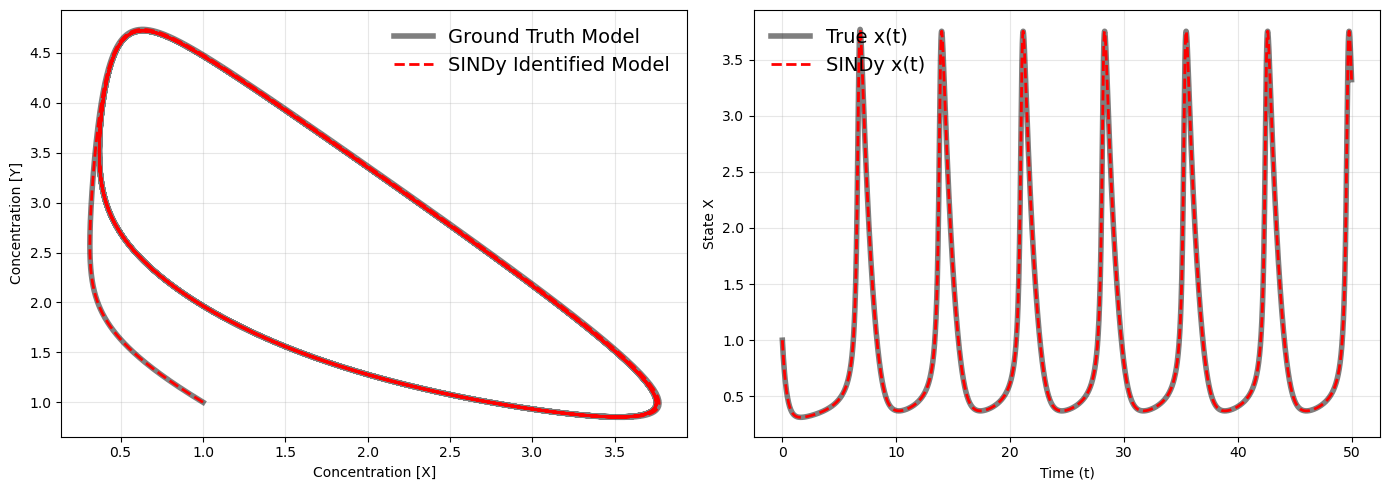

In [15]:
# Simulation Accuracy

# Because the limit cycle is stable (not chaotic), the SINDy model 
# should track the true trajectory perfectly for the entire duration.
X_brus_sim = model_brus.simulate(initial_state_brus, t_brus)

fig = plt.figure(figsize=(14, 5))

# Plot 1: 2D Phase Portrait
ax1 = fig.add_subplot(121)
ax1.plot(X_brus[:, 0], X_brus[:, 1], 'k', lw=4, label="Ground Truth Model", alpha=0.5)
ax1.plot(X_brus_sim[:, 0], X_brus_sim[:, 1], 'r--', lw=2, label="SINDy Identified Model")
ax1.set_xlabel("Concentration [X]")
ax1.set_ylabel("Concentration [Y]")
ax1.legend(frameon=False, fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Time Series
ax2 = fig.add_subplot(122)
ax2.plot(t_brus, X_brus[:, 0], 'k', lw=4, label="True x(t)", alpha=0.5)
ax2.plot(t_brus, X_brus_sim[:, 0], 'r--', lw=2, label="SINDy x(t)")
ax2.set_xlabel("Time (t)")
ax2.set_ylabel("State X")
ax2.legend(frameon=False, fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
#### Part 3: Failure Cases

SINDy relies on the assumptions of sparsity of model and high-quality data. Here we deliberately break the algorithm to explore two vulnerabilities:

* Failure Case 1: Low Sampling Rate
* Failure Case 2: Missing Terms

##### Failure Case 1: Lorenz & Low Sampling Rate

In [16]:
# 1. Generate low-sampling-rate Data

dt_low = 0.1  # 100x larger time step
t_max_low = 50.0
t_low = np.arange(0, t_max_low, dt_low)

sol_low = solve_ivp(
    lorenz_deriv, 
    t_span=(0, t_max_low), 
    y0=[-8.0, 8.0, 27.0], 
    t_eval=t_low, 
    method='LSODA', rtol=1e-12, atol=1e-12
)
X_low = sol_low.y.T 

# Fit SINDy using the same parameters as in the "Success" case
model_low = ps.SINDy(
    differentiation_method=ps.FiniteDifference(order=4), 
    feature_library=ps.PolynomialLibrary(degree=5),
    optimizer=ps.STLSQ(threshold=0.025)
)

model_low.fit(X_low, t=dt_low, feature_names=["x", "y", "z"])

,optimizer,STLSQ(threshold=0.025)
,feature_library,PolynomialLibrary(degree=5)
,differentiation_method,FiniteDifference(order=4)
,degree,5
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.025
,alpha,0.05
,max_iter,20


In [17]:
# Structural Failure
model_low.print()

(x)' =  1.749 1 + -9.237 x +  9.225 y + -0.107 z +  0.058 x^2 + -0.095 x y +  0.038 y^2
(y)' = -0.769 1 +  15.746 x +  3.474 y + -0.654 x z + -0.089 y z
(z)' =  12.602 1 +  0.033 x + -3.605 z +  0.642 x^2 +  1.710 x y + -0.277 y^2 + -0.032 x y z


In [18]:
# Prediction Performance

score_low = model_low.score(X_low, t=dt_low)
print(f"Model Score: {score_low:.4f}")

# Note that the score is decent while the identified equations are structurally wrong.

Model Score: 0.9736


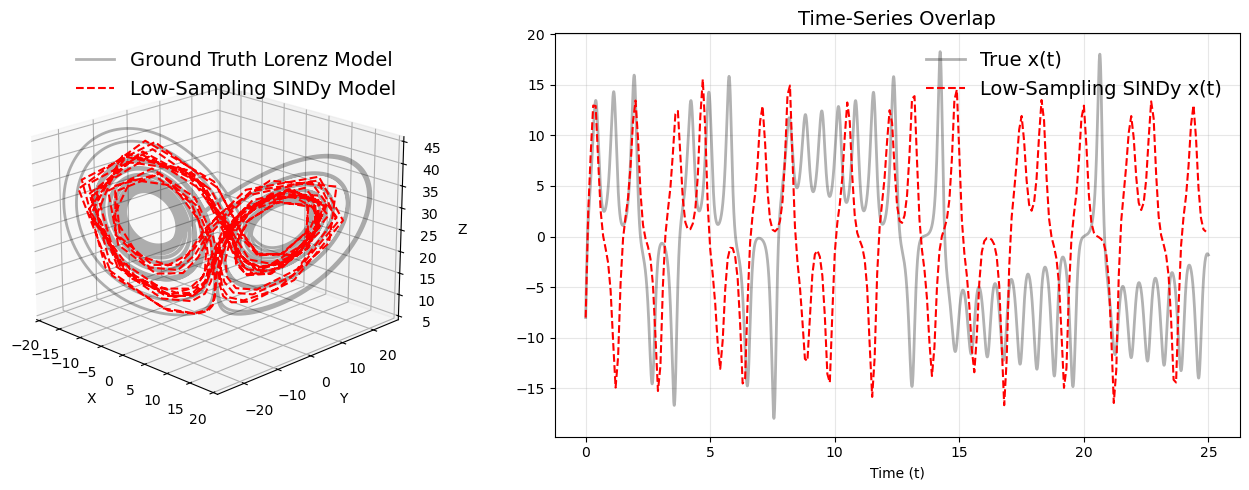

In [19]:
# Simulation Performance

t_sim_low = np.arange(0, 25, 0.1)
X_low_sim = model_low.simulate([-8.0, 8.0, 27.0], t_sim_low)

fig = plt.figure(figsize=(14, 5))

# Plot 1: 3D Phase Portrait
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_lor[:, 0], X_lor[:, 1], X_lor[:, 2], 'k', lw=2, label="Ground Truth Lorenz Model", alpha=0.3)
ax1.plot(X_low_sim[:, 0], X_low_sim[:, 1], X_low_sim[:, 2], 'r--', lw=1.5, label="Low-Sampling SINDy Model")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.legend(frameon=False, fontsize=14)
ax1.view_init(elev=20, azim=-45)

# Plot 2: Time Series
ax2 = fig.add_subplot(122)
ax2.plot(t_lor, X_lor[:, 0], 'k', lw=2, label="True x(t)", alpha=0.3)
ax2.plot(t_sim_low, X_low_sim[:, 0], 'r--', lw=1.5, label="Low-Sampling SINDy x(t)")
ax2.set_title("Time-Series Overlap", fontsize=14)
ax2.set_xlabel("Time (t)")
ax2.legend(frameon=False, fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Failure Case 2: Brusselator & Missting Terms

In [20]:
# Build the custom library using Library Addition (with missing terms)
# We provide up to 2nd order polynomials + sin/cos, intentionally omitting x^2 y
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=True)
fourier_lib = ps.FourierLibrary(n_frequencies=1)

# This combines [1, x, y, x^2, xy, y^2] with [sin(x), cos(x), sin(y), cos(y)]
missing_lib = poly_lib + fourier_lib

# Fit SINDy to the original Brusselator data using the missing library
model_missing = ps.SINDy(
    differentiation_method=ps.FiniteDifference(order=4),
    feature_library=missing_lib,
    optimizer=ps.STLSQ(threshold=0.1)
)

model_missing.fit(X_brus, t=dt_brus, feature_names=["x", "y"])


,optimizer,STLSQ()
,feature_library,ConcatLibrary...ierLibrary()])
,differentiation_method,FiniteDifference(order=4)
,libraries,"[PolynomialLibrary(), FourierLibrary()]"
,threshold,0.1
,alpha,0.05
,max_iter,20
,ridge_kw,None
,normalize_columns,False
,copy_X,True
,initial_guess,None


In [21]:
# Structural Failure

model_missing.print()

(x)' = -12.470 1 + -13.196 x +  17.727 y +  2.131 x^2 +  2.146 x y + -2.900 y^2 + -0.036 sin(1 x) + -5.811 cos(1 x) +  0.594 sin(1 y) +  7.163 cos(1 y)
(y)' =  13.470 1 +  12.196 x + -17.727 y + -2.131 x^2 + -2.146 x y +  2.900 y^2 +  0.036 sin(1 x) +  5.811 cos(1 x) + -0.594 sin(1 y) + -7.163 cos(1 y)


In [22]:
# Prediction Performance
score_missing = model_missing.score(X_brus, t=dt_brus)
print(f"Model Score: {score_missing:.4f}")

Model Score: 0.9845


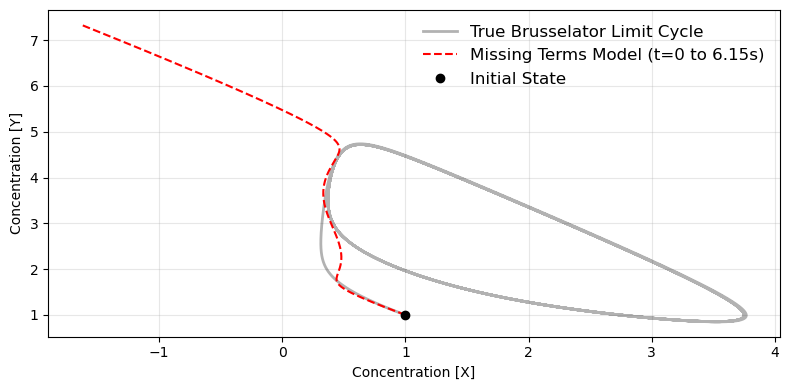

In [23]:
# Simulation Performance

# SINDy Idetified Model
def missing_terms_model(t, state):
    x, y = state
    
    dx = (-12.470 
          - 13.196*x + 17.727*y 
          + 2.131*x**2 + 2.146*x*y - 2.900*y**2 
          - 0.036*np.sin(x) - 5.811*np.cos(x) 
          + 0.594*np.sin(y) + 7.163*np.cos(y))
    
    dy = (13.470 
          + 12.196*x - 17.727*y 
          - 2.131*x**2 - 2.146*x*y + 2.900*y**2 
          + 0.036*np.sin(x) + 5.811*np.cos(x) 
          - 0.594*np.sin(y) - 7.163*np.cos(y))
    
    return [dx, dy]

#  Simulate explicitly using LSODA
# We only simulate for 6.15 seconds. 
# 6.15s is the maximum stable integration time we found after testing. 
# If we go longer, the system blows up to infinity and there's overflow errors.
t_short = np.arange(0, 6.15, 0.01)

sol_missing = solve_ivp(
    missing_terms_model, 
    t_span=(0, 6.15), 
    y0=[1.0, 1.0],  # Same initial conditions
    t_eval=t_short, 
    method='LSODA'
)

X_missing_sim = sol_missing.y.T

# Visualization
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)

# True limit cycle reference
ax.plot(X_brus[:, 0], X_brus[:, 1], 'k', lw=2, label="True Brusselator Limit Cycle", alpha=0.3)

# Plot our missing terms model
ax.plot(X_missing_sim[:, 0], X_missing_sim[:, 1], 'r--', lw=1.5, label="Missing Terms Model (t=0 to 6.15s)")

ax.plot(1.0, 1.0, 'ko', markersize=6, label="Initial State")

ax.set_xlabel("Concentration [X]")
ax.set_ylabel("Concentration [Y]")
ax.legend(frameon=False, fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()